[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/notebooks/name-generation-rnn.ipynb)

# Character-Level Name Generation with RNN

This notebook demonstrates how to build a character-level Recurrent Neural Network (RNN) using PyTorch Lightning to generate realistic names. We'll train on a dataset of real names and learn the patterns to generate new, plausible names.

## What You'll Learn
- Character-level language modeling
- RNN implementation with PyTorch Lightning
- Training sequence-to-sequence models
- Autoregressive text generation

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as L
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from collections import Counter

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)
L.seed_everything(42)

print(f"PyTorch: {torch.__version__}")
print(f"Lightning: {L.__version__}")

Seed set to 42


PyTorch: 2.9.0
Lightning: 2.5.5


## 1. Data Loading and Preprocessing

We'll download a dataset of names and prepare it for character-level modeling.

In [2]:
# Download the names dataset
url = 'https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt'
names_file = 'names.txt'

print(f"Downloading names dataset from {url}...")
urllib.request.urlretrieve(url, names_file)

# Load names
with open(names_file, 'r') as f:
    names = f.read().splitlines()

# Filter out empty lines and convert to lowercase
names = [name.strip().lower() for name in names if name.strip()]

print(f"\nTotal names: {len(names)}")
print(f"\nSample names: {names[:10]}")
print(f"\nName length stats:")
print(f"  Min: {min(len(n) for n in names)}")
print(f"  Max: {max(len(n) for n in names)}")
print(f"  Mean: {np.mean([len(n) for n in names]):.1f}")


Total names: 32033

Sample names: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']

Name length stats:
  Min: 2
  Max: 15
  Mean: 6.1


## 2. Building the Vocabulary

Create a character-to-index mapping. We'll use special tokens:
- `.` : Start/End of sequence marker
- All lowercase letters a-z

In [3]:
# Build character vocabulary
chars = sorted(list(set(''.join(names))))
chars = ['.'] + chars  # Add special start/end token

# Create mappings
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}
vocab_size = len(chars)

print(f"Vocabulary size: {vocab_size}")
print(f"Characters: {''.join(chars)}")
print(f"\nExample encoding:")
print(f"  'emma' -> {[char_to_idx[c] for c in 'emma']}")

Vocabulary size: 27
Characters: .abcdefghijklmnopqrstuvwxyz

Example encoding:
  'emma' -> [5, 13, 13, 1]


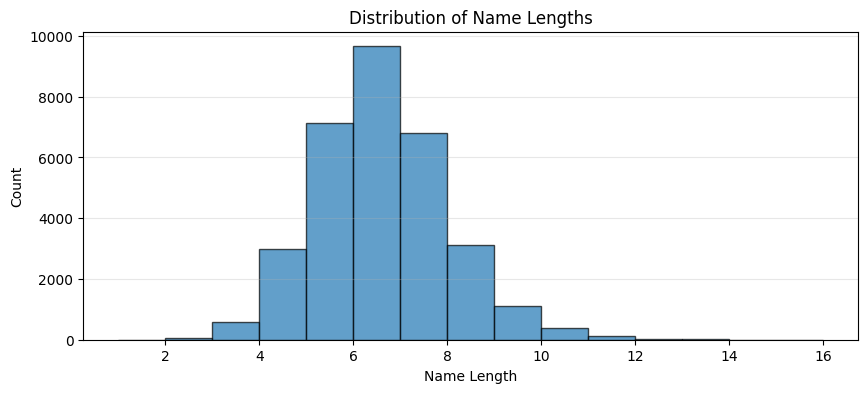

In [4]:
# Visualize name length distribution
name_lengths = [len(name) for name in names]

plt.figure(figsize=(10, 4))
plt.hist(name_lengths, bins=range(1, max(name_lengths) + 2), edgecolor='black', alpha=0.7)
plt.xlabel('Name Length')
plt.ylabel('Count')
plt.title('Distribution of Name Lengths')
plt.grid(axis='y', alpha=0.3)
plt.show()

## 3. Create Dataset

We'll create a dataset where:
- Input: character sequence `.name` (with start token)
- Target: shifted sequence `name.` (with end token)

The model learns to predict the next character given the previous ones.

In [5]:
class NamesDataset(Dataset):
    """Character-level names dataset for sequence modeling."""
    
    def __init__(self, names, char_to_idx, max_length=None):
        self.names = names
        self.char_to_idx = char_to_idx
        self.max_length = max_length or max(len(n) for n in names) + 1  # +1 for start token
    
    def __len__(self):
        return len(self.names)
    
    def __getitem__(self, idx):
        name = self.names[idx]
        
        # Add start and end tokens
        name_with_tokens = '.' + name + '.'
        
        # Convert to indices
        indices = [self.char_to_idx[ch] for ch in name_with_tokens]
        
        # Input: all but last character
        # Target: all but first character
        x = torch.tensor(indices[:-1], dtype=torch.long)
        y = torch.tensor(indices[1:], dtype=torch.long)
        
        return x, y

# Create dataset
dataset = NamesDataset(names, char_to_idx)

# Split into train/val
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Show example
x, y = dataset[0]
print(f"\nExample:")
print(f"  Name: {names[0]}")
print(f"  Input indices: {x.tolist()}")
print(f"  Input chars: {''.join([idx_to_char[i.item()] for i in x])}")
print(f"  Target indices: {y.tolist()}")
print(f"  Target chars: {''.join([idx_to_char[i.item()] for i in y])}")

Training samples: 28829
Validation samples: 3204

Example:
  Name: emma
  Input indices: [0, 5, 13, 13, 1]
  Input chars: .emma
  Target indices: [5, 13, 13, 1, 0]
  Target chars: emma.


In [6]:
def collate_fn(batch):
    """Collate function to pad sequences in a batch."""
    xs, ys = zip(*batch)
    
    # Pad sequences
    xs_padded = nn.utils.rnn.pad_sequence(xs, batch_first=True, padding_value=0)
    ys_padded = nn.utils.rnn.pad_sequence(ys, batch_first=True, padding_value=-100)  # -100 is ignored by CrossEntropyLoss
    
    return xs_padded, ys_padded

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 226
Val batches: 26


## 4. Build the Model

We'll create a character-level language model using a vanilla RNN (Recurrent Neural Network). The architecture:
1. **Embedding**: Convert character indices to dense vectors
2. **RNN**: Process the sequence and capture temporal patterns
3. **Linear**: Project to vocabulary size for character prediction

**Note:** We're using a basic RNN here. For better performance on longer sequences, consider GRU or LSTM which handle vanishing gradients better.

In [ ]:
class NameGeneratorRNN(L.LightningModule):
    """Character-level RNN for name generation."""
    
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int = 64,
        hidden_size: int = 256,
        num_layers: int = 2,
        dropout: float = 0.2,
        learning_rate: float = 1e-3,
    ):
        super().__init__()
        self.save_hyperparameters()
        
        # Model layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(
            embedding_dim,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)
        
        # Loss
        self.criterion = nn.CrossEntropyLoss()
    
    def forward(self, x, hidden=None):
        """Forward pass.
        
        Args:
            x: Input indices (batch, seq_len)
            hidden: Optional hidden state
        
        Returns:
            logits: (batch, seq_len, vocab_size)
            hidden: Final hidden state
        """
        # Embed characters
        embedded = self.embedding(x)  # (batch, seq_len, embedding_dim)
        
        # RNN forward
        rnn_out, hidden = self.rnn(embedded, hidden)  # (batch, seq_len, hidden_size)
        
        # Apply dropout and project to vocabulary
        rnn_out = self.dropout(rnn_out)
        logits = self.fc(rnn_out)  # (batch, seq_len, vocab_size)
        
        return logits, hidden
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits, _ = self(x)
        
        # Reshape for loss calculation
        loss = self.criterion(logits.view(-1, self.hparams.vocab_size), y.view(-1))
        
        self.log('train_loss', loss, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits, _ = self(x)
        
        # Reshape for loss calculation
        loss = self.criterion(logits.view(-1, self.hparams.vocab_size), y.view(-1))
        
        self.log('val_loss', loss, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
    
    @torch.no_grad()
    def generate(self, char_to_idx, idx_to_char, max_length=20, temperature=1.0, num_samples=1):
        """Generate new names.
        
        Args:
            char_to_idx: Character to index mapping
            idx_to_char: Index to character mapping
            max_length: Maximum name length
            temperature: Sampling temperature (higher = more random)
            num_samples: Number of names to generate
        
        Returns:
            List of generated names
        """
        self.eval()
        generated_names = []
        
        for _ in range(num_samples):
            # Start with start token
            current_idx = char_to_idx['.']
            name_chars = []
            hidden = None
            
            for _ in range(max_length):
                # Get model prediction
                x = torch.tensor([[current_idx]], dtype=torch.long, device=self.device)
                logits, hidden = self(x, hidden)
                
                # Sample next character
                probs = F.softmax(logits[0, -1] / temperature, dim=0)
                next_idx = torch.multinomial(probs, 1).item()
                next_char = idx_to_char[next_idx]
                
                # Stop if we hit end token
                if next_char == '.':
                    break
                
                name_chars.append(next_char)
                current_idx = next_idx
            
            generated_names.append(''.join(name_chars))
        
        return generated_names

# Initialize model
model = NameGeneratorRNN(
    vocab_size=vocab_size,
    embedding_dim=64,
    hidden_size=256,
    num_layers=2,
    dropout=0.2,
    learning_rate=1e-3,
)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

## 5. Training

Let's train the model! The loss will decrease as the model learns character patterns in names.

In [8]:
# Configure trainer
trainer = L.Trainer(
    max_epochs=30,
    accelerator='auto',
    devices=1,
    enable_progress_bar=True,
    log_every_n_steps=20,
)

# Train
print("Starting training...\n")
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

  | Name      | Type             | Params | Mode 
-------------------------------------------------------
0 | embeddin

Starting training...



Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


## 6. Generate Names

Now let's use our trained model to generate new names! We can control creativity with the temperature parameter:
- Lower temperature (< 1.0): More conservative, realistic names
- Higher temperature (> 1.0): More creative, diverse names

In [9]:
# Generate names with different temperatures
print("Generated Names:\n")

for temp in [0.5, 0.8, 1.0, 1.2]:
    print(f"\nTemperature {temp}:")
    generated = model.generate(
        char_to_idx, 
        idx_to_char, 
        max_length=15, 
        temperature=temp, 
        num_samples=10
    )
    
    # Capitalize first letter
    generated = [name.capitalize() for name in generated]
    print("  " + ", ".join(generated))

Generated Names:


Temperature 0.5:
  Areli, Ashland, Azelia, Marleigha, Karsyn, Robrin, Marianne, Marlow, Akin, Jaicee

Temperature 0.8:
  Antonino, Brodan, Alexis, Karolynn, Taycee, Armanii, Alexie, Aliah, Erich, Beliana

Temperature 1.0:
  Bellazyn, Zerayah, Jaimy, Michael, Casby, Kiara, Aben, Dansh, Aadyn, Javi

Temperature 1.2:
  Jeremyah, Anihukay, Breylus, Makryn, Rozelle, Ihana, Zoltan, Shalva, Brennynce, Je


In [10]:
# Generate a larger sample to analyze
print("Generating 100 names for analysis...\n")
large_sample = model.generate(
    char_to_idx, 
    idx_to_char, 
    max_length=15, 
    temperature=0.8, 
    num_samples=100
)

# Filter out empty names
large_sample = [name for name in large_sample if name]

# Create a set of original names (lowercase) for fast lookup
original_names_set = set(names)

# Separate into new vs existing names
new_names = [name for name in large_sample if name not in original_names_set]
existing_names = [name for name in large_sample if name in original_names_set]

# Capitalize for display
large_sample_display = [name.capitalize() for name in large_sample]
new_names_display = [name.capitalize() for name in new_names]
existing_names_display = [name.capitalize() for name in existing_names]

# Print novelty statistics
print("=" * 60)
print("NOVELTY ANALYSIS")
print("=" * 60)
print(f"\nTotal generated: {len(large_sample)}")
print(f"Unique generated: {len(set(large_sample))}")
print(f"\n✨ NEW names (not in dataset): {len(new_names)} ({len(new_names)/len(large_sample)*100:.1f}%)")
print(f"♻️  EXISTING names (memorized): {len(existing_names)} ({len(existing_names)/len(large_sample)*100:.1f}%)")

# Show examples of new names
print(f"\n{'-'*60}")
print("Examples of NEW generated names:")
print(f"{'-'*60}")
for i in range(0, min(30, len(new_names_display)), 5):
    print("  " + ", ".join(new_names_display[i:i+5]))

# Show examples of existing names (if any)
if existing_names_display:
    print(f"\n{'-'*60}")
    print("Examples of EXISTING names (from dataset):")
    print(f"{'-'*60}")
    for i in range(0, min(20, len(existing_names_display)), 5):
        print("  " + ", ".join(existing_names_display[i:i+5]))

# General statistics
print(f"\n{'-'*60}")
print("Generated name statistics:")
print(f"{'-'*60}")
print(f"  Average length: {np.mean([len(n) for n in large_sample]):.1f}")
print(f"  Length range: {min(len(n) for n in large_sample)} - {max(len(n) for n in large_sample)}")

Generating 100 names for analysis...

NOVELTY ANALYSIS

Total generated: 100
Unique generated: 100

✨ NEW names (not in dataset): 32 (32.0%)
♻️  EXISTING names (memorized): 68 (68.0%)

------------------------------------------------------------
Examples of NEW generated names:
------------------------------------------------------------
  Foleston, Carmie, Redietna, Leulah, Linklee
  Ellari, Natson, Kashat, Anler, Lanstan
  Nathelia, Mayceus, Yanali, Aligha, Enaida
  Reil, Jahlan, Ananha, Danayia, Missa
  Tacum, Tessiel, Kariel, Intisan, Oluwatimilore
  Zarhan, Kelmin, Mariaw, Fend, Laurin

------------------------------------------------------------
Examples of EXISTING names (from dataset):
------------------------------------------------------------
  Charla, Karsen, Yuriel, Tristian, Mahati
  Katya, Harmonie, Kiyla, Saraya, Jermany
  Caroline, Jameer, Kastin, Mariem, Azaiah
  Jaelyne, Amarion, Assad, Sheri, Laken

------------------------------------------------------------
Genera

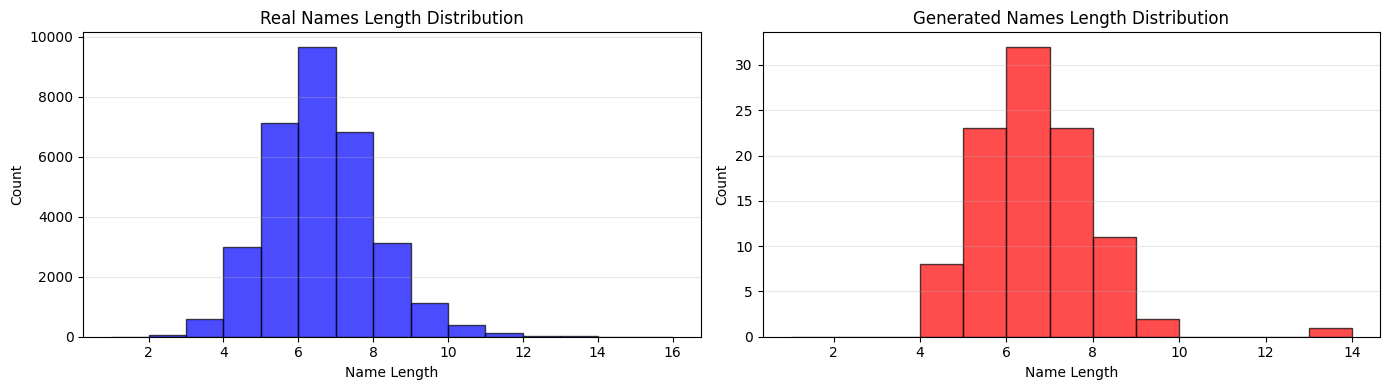


Mean length - Real: 6.1, Generated: 6.2


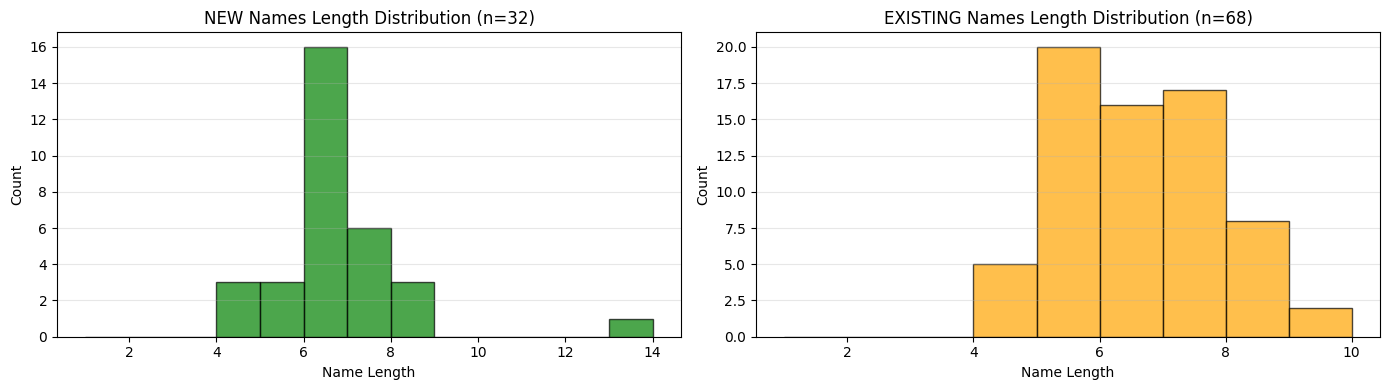


Mean length - New: 6.3, Existing: 6.1


In [11]:
# Visualize generated vs real name lengths
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Real names
real_lengths = [len(name) for name in names]
ax1.hist(real_lengths, bins=range(1, max(real_lengths) + 2), edgecolor='black', alpha=0.7, color='blue')
ax1.set_xlabel('Name Length')
ax1.set_ylabel('Count')
ax1.set_title('Real Names Length Distribution')
ax1.grid(axis='y', alpha=0.3)

# Generated names
gen_lengths = [len(name) for name in large_sample]
ax2.hist(gen_lengths, bins=range(1, max(gen_lengths) + 2), edgecolor='black', alpha=0.7, color='red')
ax2.set_xlabel('Name Length')
ax2.set_ylabel('Count')
ax2.set_title('Generated Names Length Distribution')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMean length - Real: {np.mean(real_lengths):.1f}, Generated: {np.mean(gen_lengths):.1f}")

# Additional visualization: New vs Existing names
if new_names and existing_names:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    # New names
    new_lengths = [len(name) for name in new_names]
    ax1.hist(new_lengths, bins=range(1, max(new_lengths) + 2), edgecolor='black', alpha=0.7, color='green')
    ax1.set_xlabel('Name Length')
    ax1.set_ylabel('Count')
    ax1.set_title(f'NEW Names Length Distribution (n={len(new_names)})')
    ax1.grid(axis='y', alpha=0.3)
    
    # Existing names
    existing_lengths = [len(name) for name in existing_names]
    ax2.hist(existing_lengths, bins=range(1, max(existing_lengths) + 2), edgecolor='black', alpha=0.7, color='orange')
    ax2.set_xlabel('Name Length')
    ax2.set_ylabel('Count')
    ax2.set_title(f'EXISTING Names Length Distribution (n={len(existing_names)})')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nMean length - New: {np.mean(new_lengths):.1f}, Existing: {np.mean(existing_lengths):.1f}")

## Key Takeaways

1. **Character-level modeling**: We can model language at the character level, learning patterns without explicit vocabulary

2. **Sequence modeling**: Vanilla RNNs are effective at capturing sequential patterns in text for short sequences like names

3. **Autoregressive generation**: By sampling one character at a time, we can generate arbitrary-length sequences

4. **Temperature control**: Temperature parameter controls the randomness of generation

5. **Novelty vs Memorization**: The model can both memorize existing names and generate truly novel ones - tracking this helps evaluate creativity

6. **PyTorch Lightning**: Clean, organized training with minimal boilerplate

## Experiments to Try

1. **Architecture variations**:
   - Try GRU or LSTM instead of vanilla RNN (better for longer sequences and handling vanishing gradients)
   - Experiment with different hidden sizes (128, 512)
   - Add more layers
   - Compare parameter counts: RNN vs GRU vs LSTM

2. **Training improvements**:
   - Train longer (50-100 epochs)
   - Try different learning rates
   - Add learning rate scheduling
   - Experiment with different dropout rates to reduce memorization

3. **Generation techniques**:
   - Implement beam search
   - Try top-k or nucleus sampling
   - Condition on starting characters
   - Add diversity penalties to encourage more novel names

4. **Other datasets**:
   - Try different languages
   - Generate other types of text (cities, companies, etc.)
   - Mix multiple name datasets